# Modelos de clasificación para aprendizaje automático relacional

En este notebook se entrenan y comparan varios modelos de clasificación para predecir la clase de los nodos del dataset Cora.

Se comparan tres conjuntos de características:

- **Features relacionales**: métricas calculadas a partir de la estructura del grafo.
- **Features nativas**: atributos propios de los nodos, representados como variables `word_*`.
- **Features combinadas**: unión de las features relacionales y las nativas.

Los modelos utilizados son:

- Árbol de decisión.
- KNN.
- Random Forest.

Además, se aplica ajuste de hiperparámetros mediante `GridSearchCV` sobre algunos modelos.

In [1]:
%pip install pandas numpy scikit-learn matplotlib joblib

# ============================================
# 1. IMPORTS
# ============================================

import os
import joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Carga del dataset

Se carga el fichero `features.csv`, que contiene una fila por cada nodo del grafo.  
Cada fila incluye métricas relacionales, atributos nativos del nodo y la clase que se quiere predecir.

In [2]:
# ============================================
# 2. CARGA DEL DATASET
# ============================================

df = pd.read_csv("../data/features.csv")

print("Tamaño del dataset:", df.shape)
df.head()

Tamaño del dataset: (2485, 1444)


,node_id,degree,closeness,betweenness,pagerank,eigenvector_centrality,clustering_coef,triangles,kcore,community_louvain,...,word_1424,word_1425,word_1426,word_1427,word_1428,word_1429,word_1430,word_1431,word_1432,class
0,1033,5,0.198023,0.002886,0.000450,0.052207,0.100000,1,3,0,...,0,0,0,0,0,0,0,0,0,Genetic_Algorithms
1,35,168,0.242768,0.276114,0.013302,0.654300,0.011406,160,4,1,...,0,0,0,0,0,0,0,0,0,Genetic_Algorithms
2,103482,6,0.202958,0.005357,0.000572,0.050281,0.133333,2,3,2,...,0,0,0,0,0,0,0,0,0,Neural_Networks
3,103515,11,0.196706,0.001996,0.000899,0.072508,0.163636,9,3,1,...,0,0,0,0,0,0,0,0,0,Genetic_Algorithms
4,1050679,4,0.225962,0.028597,0.000355,0.050567,0.166667,1,3,3,...,0,0,0,0,0,0,0,0,0,Genetic_Algorithms


## 2. Exploración básica

Antes de entrenar los modelos, se revisan las columnas disponibles, la distribución de clases y la existencia de valores nulos.

In [3]:
# ============================================
# 3. EXPLORACIÓN BÁSICA
# ============================================

print("Primeras columnas:")
print(df.columns[:15].tolist())

print("Número total de columnas:", len(df.columns))

print("Distribución de clases:")
print(df["class"].value_counts())

print("Valores nulos totales:", df.isnull().sum().sum())

Primeras columnas:
['node_id', 'degree', 'closeness', 'betweenness', 'pagerank', 'eigenvector_centrality', 'clustering_coef', 'triangles', 'kcore', 'community_louvain', 'word_0', 'word_1', 'word_2', 'word_3', 'word_4']
Número total de columnas: 1444
Distribución de clases:
class
Neural_Networks           726
Genetic_Algorithms        406
Probabilistic_Methods     379
Theory                    344
Case_Based                285
Reinforcement_Learning    214
Rule_Learning             131
Name: count, dtype: int64
Valores nulos totales: 0


## 3. Separación de características

Se separan las variables predictoras en tres grupos:

- **Relacionales**: métricas obtenidas a partir del grafo.
- **Nativas**: columnas `word_*`, que representan características propias de los artículos.
- **Combinadas**: unión de las anteriores.

La variable objetivo es `class`.

In [4]:
# ============================================
# 4. SEPARACIÓN DE FEATURES
# ============================================

target = "class"

features_relacionales = [
    "degree",
    "closeness",
    "betweenness",
    "pagerank",
    "eigenvector_centrality",
    "clustering_coef",
    "triangles",
    "kcore",
    "community_louvain"
]

features_nativas = [col for col in df.columns if col.startswith("word_")]

features_combinadas = features_relacionales + features_nativas

X_rel = df[features_relacionales]
X_nat = df[features_nativas]
X_comb = df[features_combinadas]

y = df[target]

print("Features relacionales:", X_rel.shape)
print("Features nativas:", X_nat.shape)
print("Features combinadas:", X_comb.shape)
print("Variable objetivo:", y.shape)

Features relacionales: (2485, 9)
Features nativas: (2485, 1433)
Features combinadas: (2485, 1442)
Variable objetivo: (2485,)


## 4. Función de entrenamiento y evaluación

Se define una función auxiliar para entrenar un modelo, evaluarlo sobre un conjunto de prueba y guardar sus resultados.

Las métricas utilizadas son:

- Accuracy.
- Precision macro.
- Recall macro.
- F1 macro.
- Matriz de confusión.

Se utiliza F1 macro porque el problema es multiclase y esta métrica da el mismo peso a todas las clases.


In [5]:
# ============================================
# 5. FUNCIÓN DE ENTRENAMIENTO Y EVALUACIÓN
# ============================================

def entrenar_y_evaluar(nombre_modelo, modelo, nombre_features, X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
    
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
    matriz = confusion_matrix(y_test, y_pred)
    
    print("=" * 70)
    print("Modelo:", nombre_modelo)
    print("Features:", nombre_features)
    print("=" * 70)
    print("Accuracy:", accuracy)
    print("Precision macro:", precision)
    print("Recall macro:", recall)
    print("F1 macro:", f1_macro)
    print("\nMatriz de confusión:")
    print(matriz)
    
    return {
        "modelo": nombre_modelo,
        "features": nombre_features,
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1_macro
    }

## 5.1. Función auxiliar para representar resultados

Se define una función sencilla para representar gráficamente el rendimiento de cada familia de modelos. Se utiliza **F1 macro** como métrica principal, ya que es la que se ha usado para seleccionar hiperparámetros con `GridSearchCV`.

In [ ]:
# ============================================
# 6. FUNCIÓN AUXILIAR PARA GRAFICAR RESULTADOS
# ============================================

def plot_resultados_por_modelo(modelos_incluir, titulo):
    tabla_modelo = pd.DataFrame(resultados)
    tabla_modelo = tabla_modelo[tabla_modelo["modelo"].isin(modelos_incluir)].copy()
    tabla_modelo = tabla_modelo.sort_values(by="f1_macro", ascending=True)
    
    if tabla_modelo.empty:
        print("No hay resultados para representar.")
        return
    
    tabla_modelo["etiqueta"] = tabla_modelo["modelo"] + " - " + tabla_modelo["features"]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.barh(
        tabla_modelo["etiqueta"],
        tabla_modelo["f1_macro"],
        color="steelblue"
    )
    
    ax.set_xlabel("F1 macro")
    ax.set_title(titulo)
    ax.set_xlim(0, 1)
    
    for i, valor in enumerate(tabla_modelo["f1_macro"]):
        ax.text(
            valor + 0.01,
            i,
            f"{valor:.3f}",
            va="center",
            fontsize=9
        )
    
    plt.tight_layout()
    plt.show()

## 5. Árbol de decisión

Primero se entrena un árbol de decisión con los tres conjuntos de características para comprobar qué tipo de información resulta más útil.

In [8]:
# ============================================
# 7. MODELO BASE: ÁRBOL DE DECISIÓN
# ============================================

resultados = []

resultados.append(entrenar_y_evaluar(
    "Decision Tree",
    DecisionTreeClassifier(random_state=42),
    "relacionales",
    X_rel,
    y
))

resultados.append(entrenar_y_evaluar(
    "Decision Tree",
    DecisionTreeClassifier(random_state=42),
    "nativas",
    X_nat,
    y
))

resultados.append(entrenar_y_evaluar(
    "Decision Tree",
    DecisionTreeClassifier(random_state=42),
    "combinadas",
    X_comb,
    y
))


Modelo: Decision Tree
Features: relacionales
Accuracy: 0.7142857142857143
Precision macro: 0.6967640658712424
Recall macro: 0.6845512566644351
F1 macro: 0.689291211773701

Matriz de confusión:
[[ 36   2   4   2   0   5   8]
 [  0  74   4   0   3   0   0]
 [  3   8 113   6   4   0  11]
 [  1   1  16  51   2   1   4]
 [  0   2   7   2  30   0   2]
 [  3   0   1   1   0  15   6]
 [  7   1  13   4   3   5  36]]
Modelo: Decision Tree
Features: nativas
Accuracy: 0.6338028169014085
Precision macro: 0.596362938291498
Recall macro: 0.5778765474317026
F1 macro: 0.5838149428997399

Matriz de confusión:
[[ 31   3   5   2   4   7   5]
 [  1  67   9   0   0   3   1]
 [  7  10 105   4   3   2  14]
 [  4   0  18  45   2   3   4]
 [  2   4   4   2  25   1   5]
 [  2   2   5   2   1   7   7]
 [  5   6  15   1   6   1  35]]
Modelo: Decision Tree
Features: combinadas
Accuracy: 0.7505030181086519
Precision macro: 0.7219671002420311
Recall macro: 0.701015536441887
F1 macro: 0.7071234640365864

Matriz de con

## 6. Ajuste de hiperparámetros del árbol de decisión

Justo después del árbol base se aplica `GridSearchCV` sobre el árbol de decisión utilizando las features combinadas, ya que fueron las que dieron mejor resultado inicial.

La métrica utilizada para seleccionar los hiperparámetros es `f1_macro`.


In [9]:
# ============================================
# 8. AJUSTE DE HIPERPARÁMETROS: DECISION TREE
# ============================================

param_grid_arbol = {
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_arbol = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_arbol,
    cv=5,
    scoring="f1_macro"
)

grid_arbol.fit(X_comb, y)

print("Mejores hiperparámetros:")
print(grid_arbol.best_params_)

print("Mejor F1 macro medio en validación cruzada:")
print(grid_arbol.best_score_)


Mejores hiperparámetros:
{'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 10}
Mejor F1 macro medio en validación cruzada:
0.7048679744639268


In [10]:
# ============================================
# 9. EVALUACIÓN DEL ÁRBOL OPTIMIZADO
# ============================================

mejor_arbol = DecisionTreeClassifier(
    max_depth=grid_arbol.best_params_["max_depth"],
    min_samples_leaf=grid_arbol.best_params_["min_samples_leaf"],
    min_samples_split=grid_arbol.best_params_["min_samples_split"],
    random_state=42
)

resultados.append(entrenar_y_evaluar(
    "Decision Tree GridSearch",
    mejor_arbol,
    "combinadas",
    X_comb,
    y
))


Modelo: Decision Tree GridSearch
Features: combinadas
Accuracy: 0.778672032193159
Precision macro: 0.7601758175179668
Recall macro: 0.736393422129318
F1 macro: 0.7449215802415622

Matriz de confusión:
[[ 36   0   4   1   2   1  13]
 [  1  77   2   0   1   0   0]
 [  1   4 121   8   2   0   9]
 [  0   0  11  60   1   1   3]
 [  0   3   3   1  33   2   1]
 [  3   0   0   1   0  13   9]
 [  8   0   6   2   4   2  47]]


### Comparación del árbol de decisión

Se representa el rendimiento del árbol de decisión con cada conjunto de features y su versión optimizada con `GridSearchCV`.

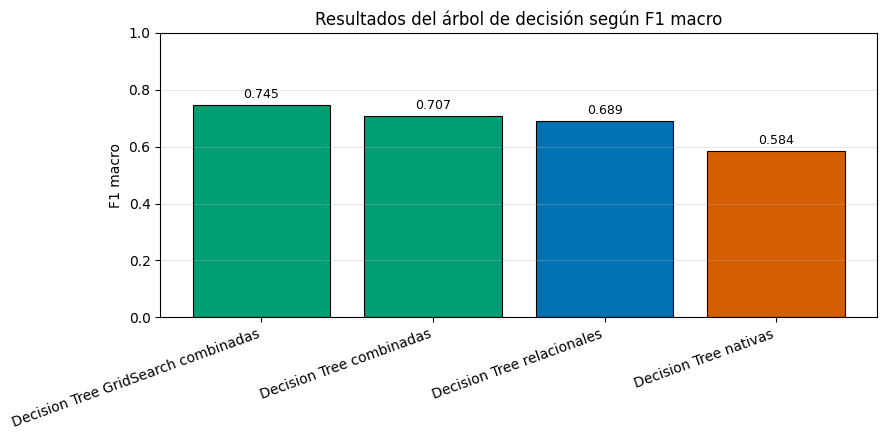

<Figure size 640x480 with 0 Axes>

In [ ]:
# ============================================
# 8. GRÁFICA: ÁRBOL DE DECISIÓN
# ============================================

plot_resultados_por_modelo(
    ["Decision Tree", "Decision Tree GridSearch"],
    "Resultados del árbol de decisión según el conjunto de features"
)



## 7. KNN

A continuación se entrena un clasificador KNN.  
Como KNN se basa en distancias, se utiliza `StandardScaler` dentro de un `Pipeline` para escalar las variables antes del entrenamiento.


In [12]:
# ============================================
# 10. MODELO BASE: KNN
# ============================================

resultados.append(entrenar_y_evaluar(
    "KNN",
    Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier())
    ]),
    "relacionales",
    X_rel,
    y
))

resultados.append(entrenar_y_evaluar(
    "KNN",
    Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier())
    ]),
    "nativas",
    X_nat,
    y
))

resultados.append(entrenar_y_evaluar(
    "KNN",
    Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier())
    ]),
    "combinadas",
    X_comb,
    y
))


Modelo: KNN
Features: relacionales
Accuracy: 0.5593561368209256
Precision macro: 0.5280906202098568
Recall macro: 0.5008897589395591
F1 macro: 0.5071133158579811

Matriz de confusión:
[[29  0 10 11  0  2  5]
 [ 0 72  9  0  0  0  0]
 [10  7 96 14  5  1 12]
 [ 7  1 23 30  6  0  9]
 [ 5  2  5  4 22  1  4]
 [ 4  1  8  1  3  5  4]
 [ 6  0 23  7  6  3 24]]
Modelo: KNN
Features: nativas
Accuracy: 0.4124748490945674
Precision macro: 0.5193530173815052
Recall macro: 0.35440863190797894
F1 macro: 0.3524170763126991

Matriz de confusión:
[[20  9 21  0  3  0  4]
 [ 2 67  9  0  1  0  2]
 [10 35 77  4  3  0 16]
 [14 14 22 11  1  0 14]
 [ 4  9 19  0 11  0  0]
 [ 1  5 12  1  1  4  2]
 [ 8 11 32  0  3  0 15]]
Modelo: KNN
Features: combinadas
Accuracy: 0.4386317907444668
Precision macro: 0.5439678500061765
Recall macro: 0.36449808796680033
F1 macro: 0.370033126793939

Matriz de confusión:
[[20  7 24  0  2  0  4]
 [ 1 67  8  0  2  0  3]
 [ 9 29 91  4  5  0  7]
 [ 8  5 35 13  1  0 14]
 [ 4  8 20  0 10  0 

## 8. Ajuste de hiperparámetros de KNN

Se aplica `GridSearchCV` sobre KNN usando las features relacionales, ya que fueron las que mejor funcionaron para este modelo en la evaluación inicial.

La métrica utilizada para seleccionar los hiperparámetros es `f1_macro`.


In [13]:
# ============================================
# 11. AJUSTE DE HIPERPARÁMETROS: KNN
# ============================================

pipeline_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid_knn = {
    "knn__n_neighbors": [3, 5, 7, 9, 11],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

grid_knn = GridSearchCV(
    pipeline_knn,
    param_grid_knn,
    cv=5,
    scoring="f1_macro"
)

grid_knn.fit(X_rel, y)

print("Mejores hiperparámetros:")
print(grid_knn.best_params_)

print("Mejor F1 macro medio en validación cruzada:")
print(grid_knn.best_score_)


Mejores hiperparámetros:
{'knn__metric': 'manhattan', 'knn__n_neighbors': 11, 'knn__weights': 'distance'}
Mejor F1 macro medio en validación cruzada:
0.5136119001469551


In [14]:
# ============================================
# 12. EVALUACIÓN DEL KNN OPTIMIZADO
# ============================================

mejor_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(
        n_neighbors=grid_knn.best_params_["knn__n_neighbors"],
        weights=grid_knn.best_params_["knn__weights"],
        metric=grid_knn.best_params_["knn__metric"]
    ))
])

resultados.append(entrenar_y_evaluar(
    "KNN GridSearch",
    mejor_knn,
    "relacionales",
    X_rel,
    y
))


Modelo: KNN GridSearch
Features: relacionales
Accuracy: 0.6056338028169014
Precision macro: 0.5862985216036296
Recall macro: 0.5787871729043127
F1 macro: 0.5809855830470341

Matriz de confusión:
[[26  0 10  9  1  3  8]
 [ 0 75  6  0  0  0  0]
 [10  8 94 11  6  1 15]
 [ 4  0 19 36  5  0 12]
 [ 3  2  4  3 28  1  2]
 [ 2  0  4  2  2 12  4]
 [ 4  0 17  7  6  5 30]]


### Comparación de KNN

Se representa el rendimiento de KNN con cada conjunto de features y su versión optimizada con `GridSearchCV`.

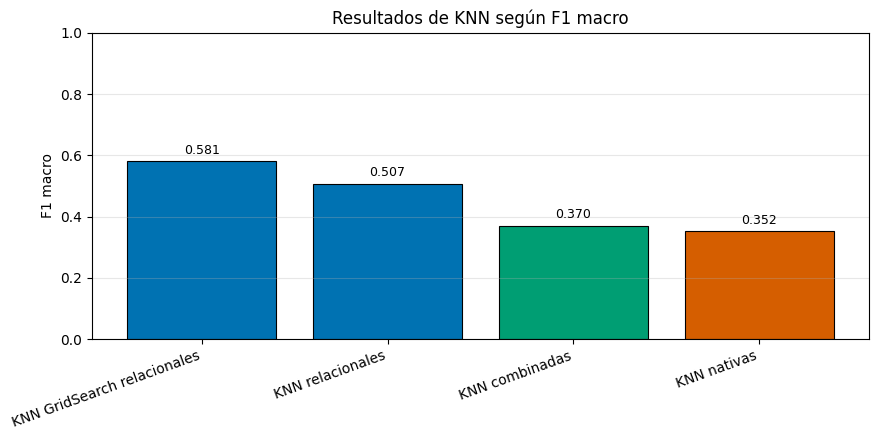

<Figure size 640x480 with 0 Axes>

In [ ]:
# ============================================
# 12. GRÁFICA: KNN
# ============================================

plot_resultados_por_modelo(
    ["KNN", "KNN GridSearch"],
    "Resultados de KNN según F1 macro"
)



## 9. Random Forest

Se entrena un Random Forest como modelo adicional.  
Este modelo combina varios árboles de decisión, lo que suele mejorar la capacidad de generalización frente a un único árbol.


In [16]:
# ============================================
# 14. MODELO BASE: RANDOM FOREST
# ============================================

resultados.append(entrenar_y_evaluar(
    "Random Forest",
    RandomForestClassifier(random_state=42),
    "relacionales",
    X_rel,
    y
))

resultados.append(entrenar_y_evaluar(
    "Random Forest",
    RandomForestClassifier(random_state=42),
    "nativas",
    X_nat,
    y
))

resultados.append(entrenar_y_evaluar(
    "Random Forest",
    RandomForestClassifier(random_state=42),
    "combinadas",
    X_comb,
    y
))


Modelo: Random Forest
Features: relacionales
Accuracy: 0.6841046277665996
Precision macro: 0.6559758047308587
Recall macro: 0.6440439485821935
F1 macro: 0.6483576132215868

Matriz de confusión:
[[ 35   0   5   3   0   4  10]
 [  0  79   1   0   1   0   0]
 [  6   8 109   8   4   0  10]
 [  1   0  18  46   4   0   7]
 [  1   4   4   3  28   2   1]
 [  3   0   5   1   0  12   5]
 [  8   0  17   4   2   7  31]]
Modelo: Random Forest
Features: nativas
Accuracy: 0.7545271629778671
Precision macro: 0.7831780123013223
Recall macro: 0.7006969361741486
F1 macro: 0.7297320897370879

Matriz de confusión:
[[ 41   1   9   0   2   0   4]
 [  1  70   8   1   0   0   1]
 [  1   4 132   1   0   0   7]
 [  6   0  17  49   1   0   3]
 [  2   6   6   0  26   0   3]
 [  2   0   3   1   1  14   5]
 [  4   2  14   2   1   3  43]]
Modelo: Random Forest
Features: combinadas
Accuracy: 0.7887323943661971
Precision macro: 0.8018045071343822
Recall macro: 0.7283431371524411
F1 macro: 0.7529249948397878

Matriz de 

## 10. Ajuste de hiperparámetros de Random Forest

Como Random Forest con features combinadas obtuvo los mejores resultados iniciales, se aplica `GridSearchCV` para ajustar sus hiperparámetros.

La métrica utilizada para seleccionar los hiperparámetros es `f1_macro`.


In [17]:
# ============================================
# 15. AJUSTE DE HIPERPARÁMETROS: RANDOM FOREST
# ============================================

param_grid_rf = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring="f1_macro"
)

grid_rf.fit(X_comb, y)

print("Mejores hiperparámetros:")
print(grid_rf.best_params_)

print("Mejor F1 macro medio en validación cruzada:")
print(grid_rf.best_score_)


Mejores hiperparámetros:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Mejor F1 macro medio en validación cruzada:
0.7454626557360738


In [18]:
# ============================================
# 16. EVALUACIÓN DEL RANDOM FOREST OPTIMIZADO
# ============================================

mejor_rf = RandomForestClassifier(
    max_depth=grid_rf.best_params_["max_depth"],
    min_samples_leaf=grid_rf.best_params_["min_samples_leaf"],
    min_samples_split=grid_rf.best_params_["min_samples_split"],
    n_estimators=grid_rf.best_params_["n_estimators"],
    random_state=42
)

resultados.append(entrenar_y_evaluar(
    "Random Forest GridSearch",
    mejor_rf,
    "combinadas",
    X_comb,
    y
))


Modelo: Random Forest GridSearch
Features: combinadas
Accuracy: 0.7907444668008048
Precision macro: 0.8082073911289809
Recall macro: 0.7401182935302962
F1 macro: 0.7650123200697541

Matriz de confusión:
[[ 37   0   8   0   2   1   9]
 [  0  80   1   0   0   0   0]
 [  1   4 133   1   1   0   5]
 [  4   0  20  51   0   0   1]
 [  0   3   6   1  30   0   3]
 [  1   0   3   1   1  15   5]
 [  6   1  11   0   1   3  47]]


### Comparación de Random Forest

Se representa el rendimiento de Random Forest con cada conjunto de features y su versión optimizada con `GridSearchCV`.

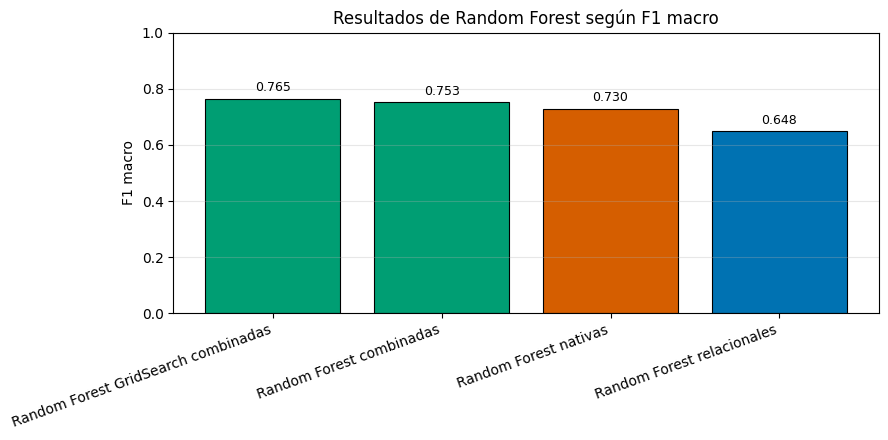

<Figure size 640x480 with 0 Axes>

In [ ]:
# ============================================
# 16. GRÁFICA: RANDOM FOREST
# ============================================

plot_resultados_por_modelo(
    ["Random Forest", "Random Forest GridSearch"],
    "Resultados de Random Forest según F1 macro"
)


## 11. Comparación final de resultados

Se construye una tabla final con todos los modelos evaluados, ordenada por F1 macro.


In [20]:
# ============================================
# 17. TABLA FINAL DE RESULTADOS
# ============================================

tabla_resultados = pd.DataFrame(resultados)

tabla_resultados = tabla_resultados.sort_values(
    by="f1_macro",
    ascending=False
)

tabla_resultados


,modelo,features,accuracy,precision_macro,recall_macro,f1_macro
11,Random Forest GridSearch,combinadas,0.790744,0.808207,0.740118,0.765012
10,Random Forest,combinadas,0.788732,0.801805,0.728343,0.752925
3,Decision Tree GridSearch,combinadas,0.778672,0.760176,0.736393,0.744922
9,Random Forest,nativas,0.754527,0.783178,0.700697,0.729732
2,Decision Tree,combinadas,0.750503,0.721967,0.701016,0.707123
0,Decision Tree,relacionales,0.714286,0.696764,0.684551,0.689291
8,Random Forest,relacionales,0.684105,0.655976,0.644044,0.648358
1,Decision Tree,nativas,0.633803,0.596363,0.577877,0.583815
7,KNN GridSearch,relacionales,0.605634,0.586299,0.578787,0.580986
4,KNN,relacionales,0.559356,0.528091,0.500890,0.507113


## 12. Visualización de resultados

Para facilitar la interpretación de los resultados, se representa gráficamente el rendimiento de cada modelo usando la métrica **F1 macro**. Esta métrica es especialmente útil en problemas multiclase, ya que calcula el rendimiento medio dando el mismo peso a todas las clases.


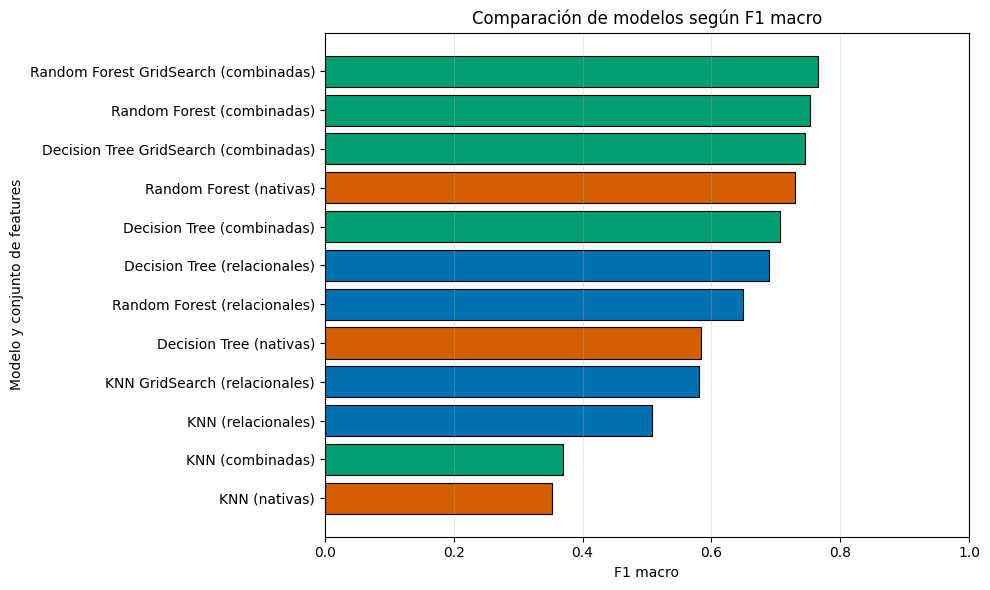

In [21]:
# ============================================
# 18. GRÁFICA COMPARATIVA DE MODELOS
# ============================================

tabla_plot = tabla_resultados.sort_values(
    by="f1_macro",
    ascending=True
).copy()

tabla_plot["modelo_features"] = (
    tabla_plot["modelo"] + " (" + tabla_plot["features"] + ")"
)

colores_features = {
    "relacionales": "#0072B2",  # azul
    "nativas": "#D55E00",       # naranja/rojo
    "combinadas": "#009E73"    # verde
}
colores = tabla_plot["features"].map(colores_features).fillna("#CC79A7")

plt.figure(figsize=(10, 6))
plt.barh(
    tabla_plot["modelo_features"],
    tabla_plot["f1_macro"],
    color=colores,
    edgecolor="black",
    linewidth=0.8
)
plt.xlabel("F1 macro")
plt.ylabel("Modelo y conjunto de features")
plt.title("Comparación de modelos según F1 macro")
plt.xlim(0, 1)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


## 13. Matriz de confusión del modelo final

Además de comparar las métricas globales, se representa la matriz de confusión del modelo final para observar en qué clases acierta más y en cuáles se producen más errores.

Se utiliza una escala de color con mayor contraste para que las diferencias entre celdas se distingan mejor.


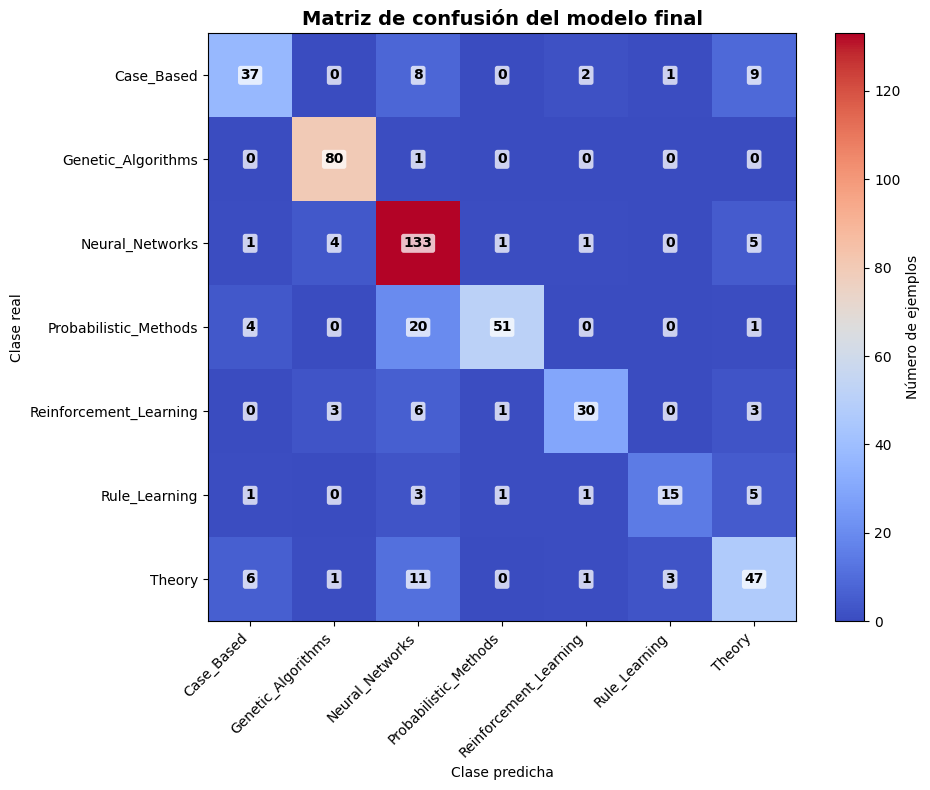

In [26]:
# ============================================
# 19. MATRIZ DE CONFUSIÓN DEL MODELO FINAL
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X_comb,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

modelo_final_grafica = RandomForestClassifier(
    max_depth=grid_rf.best_params_["max_depth"],
    min_samples_leaf=grid_rf.best_params_["min_samples_leaf"],
    min_samples_split=grid_rf.best_params_["min_samples_split"],
    n_estimators=grid_rf.best_params_["n_estimators"],
    random_state=42
)

modelo_final_grafica.fit(X_train, y_train)
y_pred_final = modelo_final_grafica.predict(X_test)

matriz_final = confusion_matrix(y_test, y_pred_final)
clases = sorted(y.unique())

plt.figure(figsize=(10, 8))

imagen = plt.imshow(
    matriz_final,
    cmap="coolwarm",
    vmin=0,
    vmax=matriz_final.max()
)

plt.title("Matriz de confusión del modelo final", fontsize=14, fontweight="bold")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.xticks(ticks=range(len(clases)), labels=clases, rotation=45, ha="right")
plt.yticks(ticks=range(len(clases)), labels=clases)
plt.colorbar(imagen, label="Número de ejemplos")


for i in range(matriz_final.shape[0]):
    for j in range(matriz_final.shape[1]):
        valor = matriz_final[i, j]
        plt.text(
            j,
            i,
            valor,
            ha="center",
            va="center",
            color="black",
            fontweight="bold",
            bbox=dict(
                facecolor="white",
                alpha=0.75,
                edgecolor="none",
                boxstyle="round,pad=0.18"
            )
        )

plt.tight_layout()
plt.show()


## 14. Serialización del modelo final

El modelo final seleccionado es Random Forest optimizado con `GridSearchCV` y entrenado con features combinadas.

Para poder reutilizarlo en un entorno limpio, se vuelve a entrenar con todos los datos disponibles y se guarda con `joblib.dump`.


In [23]:
# ============================================
# 20. SERIALIZACIÓN DEL MODELO FINAL
# ============================================

modelo_final = RandomForestClassifier(
    max_depth=grid_rf.best_params_["max_depth"],
    min_samples_leaf=grid_rf.best_params_["min_samples_leaf"],
    min_samples_split=grid_rf.best_params_["min_samples_split"],
    n_estimators=grid_rf.best_params_["n_estimators"],
    random_state=42
)

modelo_final.fit(X_comb, y)

os.makedirs("../modelo_final", exist_ok=True)

ruta_modelo = "../modelo_final/modelo_final_random_forest.joblib"

joblib.dump({
    "modelo": modelo_final,
    "features": features_combinadas,
    "target": target
}, ruta_modelo)

print("Modelo final guardado en:", ruta_modelo)


Modelo final guardado en: ../modelo_final/modelo_final_random_forest.joblib


## 15. Comprobación de carga del modelo final

Se comprueba que el fichero guardado puede cargarse correctamente y que el modelo es capaz de realizar predicciones.


In [24]:
# ============================================
# 21. COMPROBACIÓN DE CARGA DEL MODELO FINAL
# ============================================

modelo_guardado = joblib.load("../modelo_final/modelo_final_random_forest.joblib")

modelo_cargado = modelo_guardado["modelo"]
features_modelo = modelo_guardado["features"]

X_prueba = df[features_modelo].head()

predicciones = modelo_cargado.predict(X_prueba)

print("Modelo cargado correctamente.")
print("Predicciones de prueba:")
print(predicciones)


Modelo cargado correctamente.
Predicciones de prueba:
['Genetic_Algorithms' 'Genetic_Algorithms' 'Neural_Networks'
 'Genetic_Algorithms' 'Genetic_Algorithms']


## 16. Conclusiones preliminares

El mejor modelo obtenido es Random Forest con ajuste de hiperparámetros mediante `GridSearchCV` y usando features combinadas.

Los resultados muestran que combinar las métricas relacionales del grafo con las características nativas de los nodos proporciona mejores resultados que usar cada grupo de características por separado.

KNN obtiene resultados claramente inferiores al árbol de decisión y a Random Forest, incluso tras el ajuste de hiperparámetros. Esto puede deberse a que KNN depende de distancias entre ejemplos y el problema tiene un número elevado de dimensiones, especialmente al usar las features nativas o combinadas.
